# Generación de paleta de colores a partir de imágenes con técnicas de machine learning no supervisado.

El problema central radica en desarrollar un método automatizado que pueda generar una paleta coherente y estéticamente atractiva partiendo de los colores identificados en una imagen. Esto implica no solo reconocer tonos dominantes, sino también comprender la relación existente al interior de la gama cromática empleada para crear combinaciones visuales agradables y funcionales. Abordar este problema se traduciría en varias ventajas:

Eficiencia en el proceso creativo, al liberar tiempo que los autores podrían emplear en otros aspectos estratégicos de sus proyectos.

Consistencia interna en los diseños, manteniendo una identidad visual constante en diferentes aplicaciones y proyectos.

Facilidad de uso y recurso de aprendizaje para personas con menos experiencia en diseño, fomentando la creatividad en diversos campos.

Optimización de la calidad y del impacto de la comunicación visual. 

A. Objetivo.

Desarrollar un método, basado en técnicas de agrupación, que permita extraer los tonos dominantes de una imagen y generar un muestrario de los colores representativos presentes en esta. 

B. Conjunto de datos. 

Los datos están asociados con imágenes de obras de arte. Pueden ser descargados a partir de este
 enlace
.

C. Actividades para realizar.

1. Recopilación de las imágenes a partir del repositorio. La idea es seleccionar un conjunto diverso de muestras en diferentes estilos artísticos (varios pintores). Se recomienda seleccionar entre 6 y 10 imágenes.

2. Preparación de las imágenes para el entrenamiento y prueba del modelo. Para este paso construir un pipeline que integre las transformaciones que se consideren adecuadas.

3. Desarrollo del modelo de agrupación para identificar los colores dominantes en una imagen.

4. Transformación de los grupos de colores identificados en un muestrario representativo. Adicionalmente, se debería mostrar la distribución de los colores de la imagen en un espacio de dos dimensiones utilizando una técnica de reducción de la dimensionalidad.

D. Consideraciones.



## Importacion de Librerias

In [1]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth

## Cargue de imagenes:

In [ ]:
def load_images(root_path, file_names, flatten=True, normalize=True):
    """
    Retorna una lista con arreglos de números. Cada arreglo representa una imagen RGB.
    
    Parametros:
    root_path : str
        Directorio raíz de las imágenes.
    file_names : list
        Lista con los nombres de los archivos de imágenes.
    flatten : bool, opcional
        Si es True, aplana las imágenes a una lista de píxeles de tres dimensiones.
    normalize : bool, opcional
        Si es True, normaliza los valores de píxeles al rango [0, 1].
    """
    image_list = list()
    for file in file_names:
        img = cv2.imread(os.path.join(root_path, file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if flatten:
            img = img.reshape((-1, 3))
        if normalize:
            img = img / 255.0
        image_list.append(img)
    return image_list

In [28]:
#Creacion de nuestra lista de nombres de las imagenes que escogimos

lista_nombres_imagenes = os.listdir("data")
lista_nombres_imagenes


['a.y.-jackson_maple-woods-algoma-1920.jpg',
 'aaron-siskind_westport-10-1988.jpg',
 'adolf-hitler_alter-werderthor-wien.jpg',
 'albert-bloch_summer-night-1913.jpg',
 'aldo-mondino_silveti-1995.jpg',
 'donald-sultan_apples-and-oranges-1987.jpg',
 'franz-kline_mycenae-1958.jpg',
 'georges-braque_still-life-with-ace-of-hearts-1914.jpg',
 'georges-braque_the-city-on-the-hill-1909.jpg',
 'hiroshige_eagle-over-100-000-acre-plain-at-susaki-fukagawa-juman-tsubo.jpg']

In [31]:
imagenes_originales = load_images("data",lista_nombres_imagenes,False,False)
imagenes_originales

[array([[[169,  96,  41],
         [169,  96,  41],
         [169,  96,  41],
         ...,
         [171, 135, 101],
         [171, 135, 101],
         [171, 135, 101]],
 
        [[171,  98,  43],
         [171,  98,  43],
         [171,  98,  43],
         ...,
         [181, 141, 106],
         [181, 141, 106],
         [181, 141, 106]],
 
        [[172, 102,  43],
         [174, 102,  44],
         [174, 102,  44],
         ...,
         [189, 140, 107],
         [189, 140, 107],
         [189, 140, 107]],
 
        ...,
 
        [[208, 136,  51],
         [215, 143,  58],
         [218, 142,  58],
         ...,
         [165, 126,  69],
         [165, 126,  69],
         [165, 126,  69]],
 
        [[209, 137,  52],
         [216, 144,  59],
         [221, 145,  61],
         ...,
         [159, 123,  65],
         [159, 123,  65],
         [159, 123,  65]],
 
        [[210, 138,  53],
         [217, 145,  60],
         [223, 147,  63],
         ...,
         [158, 123,  65],
  

In [34]:
imagenes_convertidas = load_images("data",lista_nombres_imagenes) #no le colocamos el true true ya que por defecto esos son los valores de la función load_images
imagenes_convertidas

[array([[0.6627451 , 0.37647059, 0.16078431],
        [0.6627451 , 0.37647059, 0.16078431],
        [0.6627451 , 0.37647059, 0.16078431],
        ...,
        [0.61960784, 0.48235294, 0.25490196],
        [0.61960784, 0.48235294, 0.25490196],
        [0.61960784, 0.48235294, 0.25490196]]),
 array([[0.96862745, 0.83529412, 0.83137255],
        [0.92941176, 0.81176471, 0.80392157],
        [0.8627451 , 0.76862745, 0.75294118],
        ...,
        [0.83529412, 0.79607843, 0.76078431],
        [0.83137255, 0.78039216, 0.74901961],
        [0.80392157, 0.74509804, 0.71764706]]),
 array([[0.65098039, 0.5372549 , 0.41960784],
        [0.65098039, 0.5372549 , 0.41960784],
        [0.65490196, 0.54117647, 0.42352941],
        ...,
        [0.69019608, 0.57647059, 0.45882353],
        [0.69803922, 0.58431373, 0.46666667],
        [0.70196078, 0.58823529, 0.47058824]]),
 array([[0.70980392, 0.76078431, 0.89411765],
        [0.75686275, 0.80784314, 0.94117647],
        [0.77254902, 0.82352941, 0.

In [40]:
imagenes_originales[8].shape

(1724, 1382, 3)

In [41]:
imagenes_convertidas[8].shape

(2382568, 3)

<div style="
background:#d3f9d8;
border-left:6px solid #27b91a;
padding:16px;
border-radius:8px;
margin:12px 0;
width:1000px;
box-shadow:0 1px 4px rgba(0,0,0,0.08);
">

<b style="color:#1b5e20;">✔ Justificaciones</b><br>
No es necesario redimencionar las imagenes a un mismo tamaño ya que la tarea que queremos realizar es por cada una de las imanges, aplicando un algoritmo de agrupación por imagen para generar la paleta de colores de cada una de ellas.

</div>

In [114]:
img = 5
num_clusters = 6
lista_img_segmented = list()
list_centroids = []
for img_c, img_ori in zip(imagenes_convertidas, imagenes_originales):
    kmeans = KMeans(n_clusters=num_clusters)
    kmeans.fit(img_c)

    labels = kmeans.labels_
    centroids = kmeans.cluster_centers_
    list_centroids.append((centroids*255).astype(np.uint8).reshape(1, -1, 3))
    img_segmented = centroids[labels]*255
    img_segmented = img_segmented.reshape(img_ori.shape)
    lista_img_segmented.append(img_segmented)
   




In [112]:
list_centroids

[array([[[153,  99,  39],
         [ 93,  50,  21],
         [208, 161,  90],
         [180,  70,  17],
         [205, 114,  29]]], dtype=uint8),
 array([[[198, 195, 188],
         [ 37,  36,  31],
         [241, 241, 234],
         [ 89,  85,  78],
         [145, 141, 133]]], dtype=uint8),
 array([[[ 60,  47,  39],
         [138, 110,  86],
         [208, 186, 159],
         [107,  82,  64],
         [167, 136, 107]]], dtype=uint8),
 array([[[ 83,  82, 132],
         [195, 203, 241],
         [ 64,  46,  52],
         [113, 119, 177],
         [152, 160, 212]]], dtype=uint8),
 array([[[ 50,  50,  49],
         [210, 214, 220],
         [127,  92,  88],
         [ 72,  67,  66],
         [143, 150, 158]]], dtype=uint8),
 array([[[105, 131,  69],
         [238, 240, 237],
         [199, 160,  96],
         [ 67,  72,  58],
         [210, 108,  21]]], dtype=uint8),
 array([[[241, 201,  25],
         [241, 243, 242],
         [205,  63,  38],
         [221, 219, 212],
         [199, 138, 

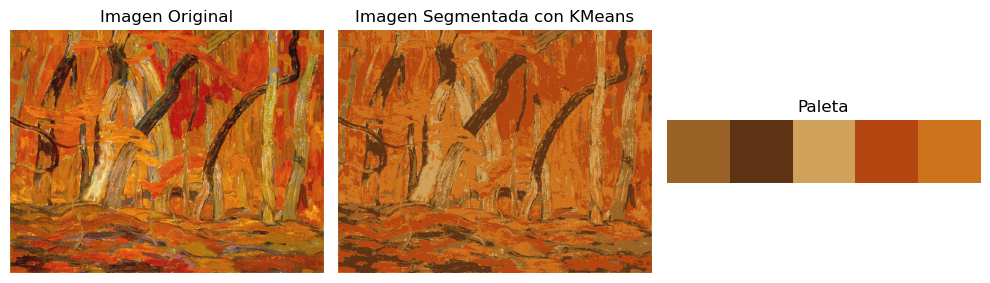

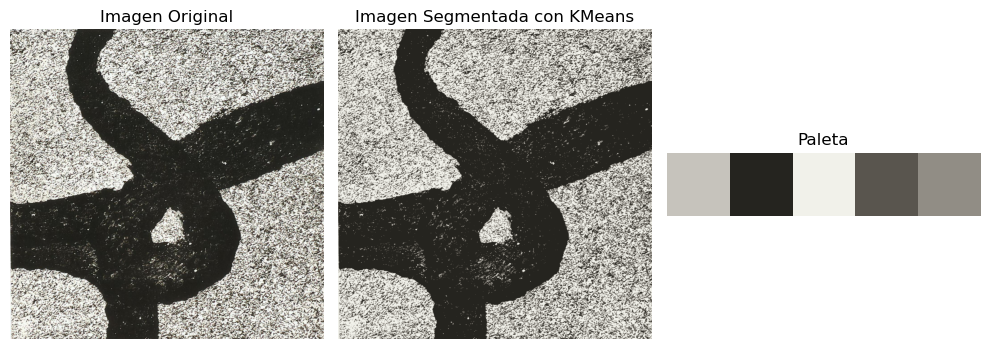

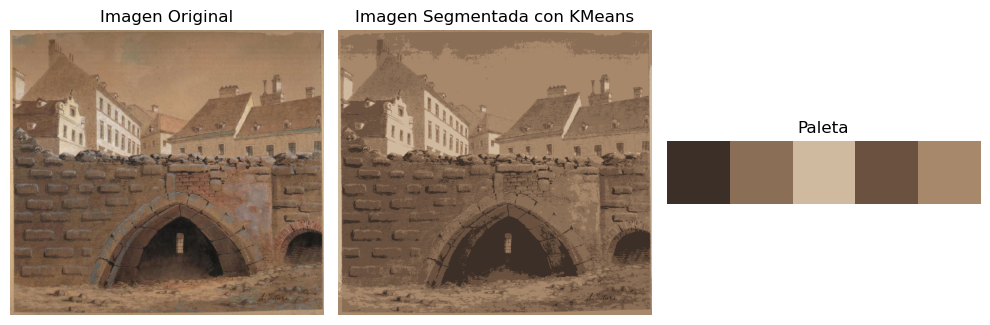

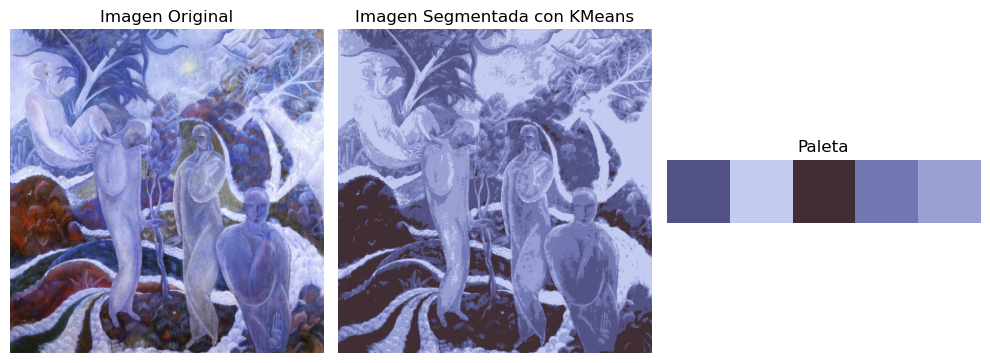

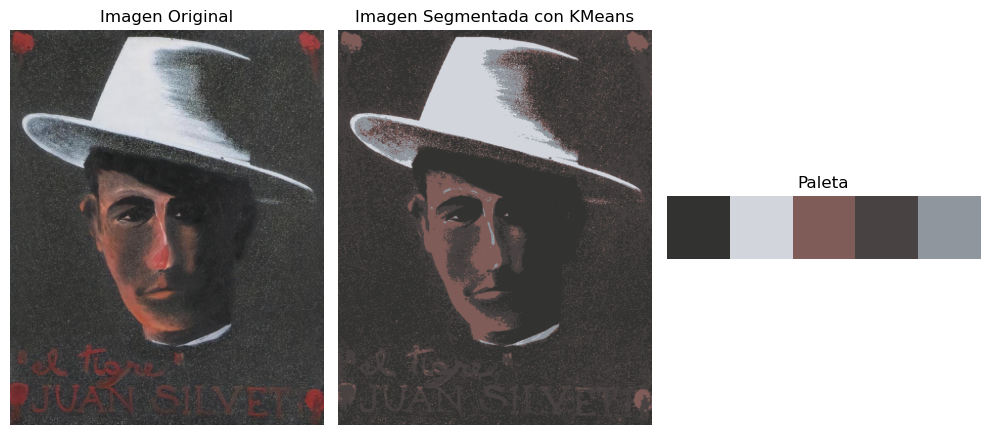

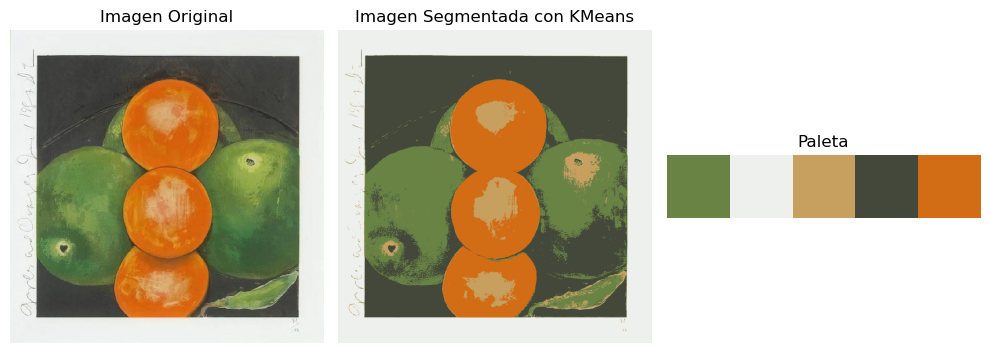

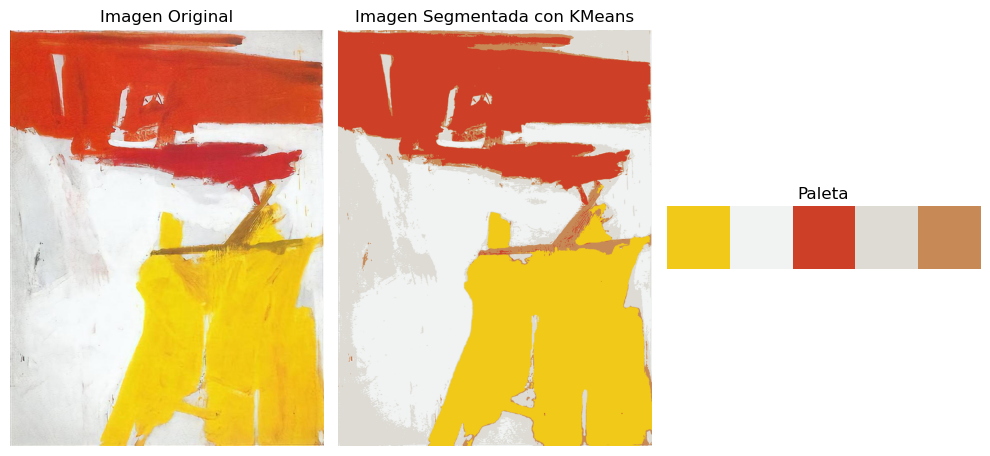

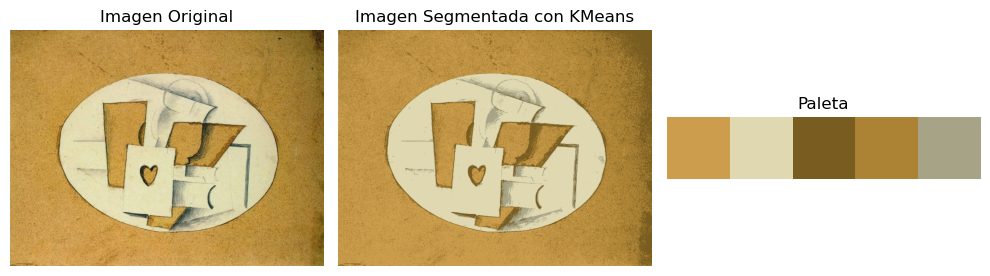

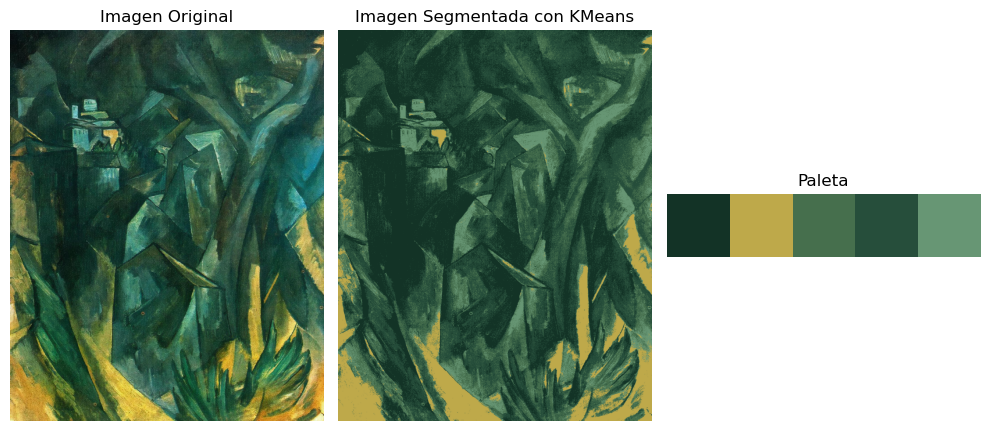

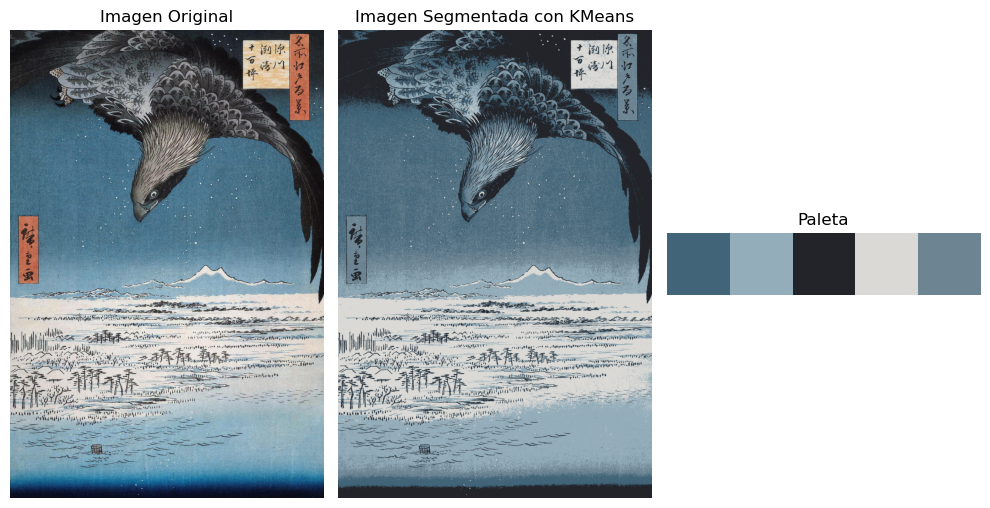

In [113]:

for img_seg,img_ori,centroi in zip(lista_img_segmented,imagenes_originales,list_centroids):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 3, 1)
    plt.title('Imagen Original')
    plt.imshow(img_ori)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title('Imagen Segmentada con KMeans')
    plt.imshow(img_seg.astype(np.uint8))
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title('Paleta')
    plt.imshow(centroi)
    plt.axis('off')

    plt.tight_layout()
    plt.show()